## <span style="color: #ffff00">Atelier Préparation de Données Textuelles</span>

### <span style="color: #ffff00">Contexte</span> 

Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 

Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client.

Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 

Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles. 

### <span style="color: #00ff0d">Partie 1 – Exploration du corpus</span>  

#### 1) Chargement des données CSV

In [2]:
import pandas as pd

df = pd.read_csv('../data/smart_reviews_raw.csv')
df

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr
...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr


#### 2) Nombre d'avis que contient le dataset

In [3]:
nombre_avis = len(df)

print(f"Le dataset contient {nombre_avis} avis clients.")

Le dataset contient 1200 avis clients.


In [4]:
# la forme complète du tableau
print(df.shape)

(1200, 8)


#### 3) Nombres de colonnes du dataset

In [6]:
# Le nombre de colonnes dans la liste des colonnes
nombre_colonnes = len(df.columns)

print(f"Le dataset possède {nombre_colonnes} colonnes.")
print("Liste des colonnes :", list(df.columns))

Le dataset possède 8 colonnes.
Liste des colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


#### 4) Le type de chaque colonne 

In [7]:
# le type de chaque colonne de manière synthétique
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

In [8]:
# On affiche un résumé technique complet du tableau
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_avis    1200 non-null   str  
 1   date       1200 non-null   str  
 2   source     1200 non-null   str  
 3   produit    1200 non-null   str  
 4   texte      1195 non-null   str  
 5   sentiment  1200 non-null   str  
 6   note       1200 non-null   int64
 7   langue     1200 non-null   str  
dtypes: int64(1), str(7)
memory usage: 75.1 KB


#### 5) Detection des valeurs manquantes

In [9]:
# Le nombre de valeurs manquantes pour chaque colonne

valeurs_manquantes = df.isnull().sum()

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)


Nombre de valeurs manquantes par colonne :
id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


#### 6) Identification quelques types de texte en affichant par exemple : texte normal ; texte vide... 

Pour isoler et afficher ces différents types de textes, on va utiliser des filtres Pandas basés sur des expressions régulières _Regex_ avec la méthode _.str.contains()_. Cela nous permet de chercher des motifs précis (comme http pour les URLs ou @ pour les mentions).

In [10]:
import re

print("EXEMPLES DE TEXTES RECHERCHÉS \n")

# Texte normal (simple, propre, sans artifice)
normal_sample = df[df['texte'] == "Excellent rapport qualité-prix."]['texte'].iloc[0]
print(f"1) Texte normal :\n-> \"{normal_sample}\"\n")

# Texte vide (ou contenant uniquement des espaces)
# On cherche les valeurs NaN détectées à la question 5

vide_sample = df[df['texte'].isnull() | (df['texte'].str.strip() == "")]['id_avis'].iloc[0]
print(f"2) Texte vide (Ligne manquante) :\n-> Identifié à l'avis : {vide_sample}\n")

# Texte contenant une URL (http ou https)

url_sample = df[df['texte'].str.contains(r'https?://\S+', na=False)]['texte'].iloc[0]
print(f"3) Texte avec URL :\n-> \"{url_sample}\"\n")

# Texte contenant une mention (@client)

mention_sample = df[df['texte'].str.contains(r'@\S+', na=False)]['texte'].iloc[0]
print(f"4) Texte avec mention :\n-> \"{mention_sample}\"\n")

# Texte contenant un hashtag (#avis)

hashtag_sample = df[df['texte'].str.contains(r'#\S+', na=False)]['texte'].iloc[0]
print(f"5) Texte avec hashtag :\n-> \"{hashtag_sample}\"\n")

# 6. Texte contenant des emojis (on cherche ici les emojis présents dans le corpus)

emoji_sample = df[df['texte'].str.contains(r'[\U00010000-\U0010ffff]', na=False)]['texte'].iloc[0]
print(f"6) Texte avec emojis :\n-> \"{emoji_sample}\"\n")

# Texte avec beaucoup de ponctuation répétée (ex: !!! ou !!!!!!!!!)

ponct_sample = df[df['texte'].str.contains(r'[!.?]{3,}', na=False)]['texte'].iloc[0]
print(f"7) Texte avec ponctuation répétée :\n-> \"{ponct_sample}\"\n")

# Texte en majuscules (complet)
# On filtre pour exclure les lignes vides, puis on vérifie si le texte est égal à sa version en majuscule

majuscule_df = df[df['texte'].notnull() & (df['texte'].str.strip() != "")]
maj_sample = majuscule_df[majuscule_df['texte'].str.isupper()]['texte'].iloc[0]
print(f"8) Texte entièrement en majuscules :\n-> \"{maj_sample}\"\n")

# Texte avec répétition de caractères (ex: trèèès)
rep_sample = df[df['texte'].str.contains(r'(.)\1{2,}', na=False)]['texte'].iloc[0]
print(f"9) Texte avec répétition de caractères :\n-> \"{rep_sample}\"\n")


EXEMPLES DE TEXTES RECHERCHÉS 

1) Texte normal :
-> "Excellent rapport qualité-prix."

2) Texte vide (Ligne manquante) :
-> Identifié à l'avis : AV0047

3) Texte avec URL :
-> "Produit parfait, rien à signaler. https://example.com/commande/17"

4) Texte avec mention :
-> "@client Livraison rapide et produit conforme à mes attentes."

5) Texte avec hashtag :
-> "Très satisfait de mon achat 👍 #avis"

6) Texte avec emojis :
-> "Très satisfait de mon achat 👍 #avis"

7) Texte avec ponctuation répétée :
-> "Produit excellent, je suis très satisfait. !!!"

8) Texte entièrement en majuscules :
-> "LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

9) Texte avec répétition de caractères :
-> "Produit excellent, je suis très satisfait. !!!"



C:\Users\cissc\AppData\Local\Temp\ipykernel_7804\738799241.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  rep_sample = df[df['texte'].str.contains(r'(.)\1{2,}', na=False)]['texte'].iloc[0]


#### 7) Mesure de la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : 
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

Pour mesurer la longueur des textes, on calcule généralement le nombre de caractères présents dans chaque phrase. En Pandas, on utilise la propriété _.str.len()_ pour réaliser ce calcul facilement.

Avant de faire le calcul, on remplace les valeurs manquantes (NaN) par une chaîne vide "" pour éviter que notre nouvelle colonne ne contienne des erreurs.

In [11]:
# On remplace les NaN par du texte vide pour éviter les erreurs de calcul
df['texte_rempli'] = df['texte'].fillna("")

# On crée la colonne 'longueur' qui compte le nombre de caractères
df['longueur'] = df['texte_rempli'].str.len()

# On supprime la colonne temporaire
df = df.drop(columns=['texte_rempli'])

# On utilise la méthode .describe() pour obtenir toutes les statistiques d'un coup
statistiques = df['longueur'].describe()
print(statistiques)

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64


Affichage lisible des longueurs

In [12]:
print(f"Longueur minimale : {df['longueur'].min()} caractères")
print(f"Longueur maximale : {df['longueur'].max()} caractères")
print(f"Longueur moyenne  : {df['longueur'].mean():.2f} caractères")
print(f"Médiane (Q2)      : {df['longueur'].median()} caractères")
print(f"Premier quartile (Q1) : {df['longueur'].quantile(0.25)} caractères")
print(f"Troisième quartile (Q3) : {df['longueur'].quantile(0.75)} caractères")

Longueur minimale : 0 caractères
Longueur maximale : 636 caractères
Longueur moyenne  : 48.96 caractères
Médiane (Q2)      : 48.0 caractères
Premier quartile (Q1) : 37.0 caractères
Troisième quartile (Q3) : 56.0 caractères


#### 8) Visualisation de la distribution de la longueur des avis 

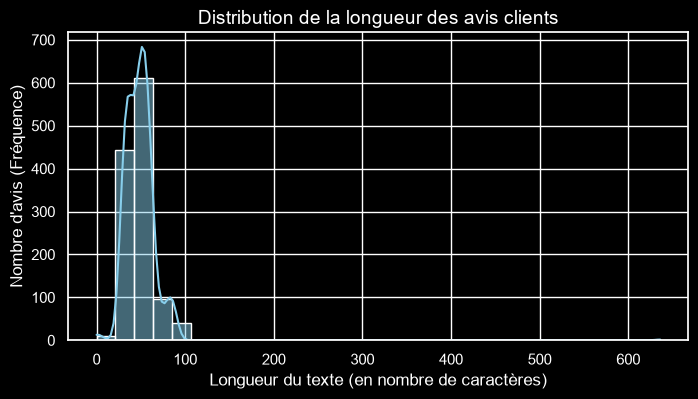

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# On configure le style graphique
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))

# On trace l'histogramme de la colonne longueur
sns.histplot(data=df, x='longueur', bins=30, kde=True, color='skyblue')

# On ajoute les titres et légendes
plt.title("Distribution de la longueur des avis clients", fontsize=14)
plt.xlabel("Longueur du texte (en nombre de caractères)", fontsize=12)
plt.ylabel("Nombre d'avis (Fréquence)", fontsize=12)

# On affiche le graphique
plt.show()

__Réponse aux question__

a) Existe-t-il des textes anormalement longs ?

Constat : Oui, absolument. On observe visuellement que la courbe s'écrase et s'étire très loin vers la droite. Alors que 75 % des avis s'arrêtent avant 63 caractères, un avis isolé grimpe jusqu'à 446 caractères.

Pourquoi ? 

En y regardant de plus près (notamment sur l'avis AV0066), on constate qu'un même motif de texte ("Le produit est bien, mais la livraison a été longue.") a été copié-collé et répété une dizaine de fois dans la même case. En Machine Learning, on appelle cela des valeurs aberrantes ou atypiques (outliers).



b) Existe-t-il beaucoup de textes très courts ?

Constat : Oui, le corpus est massivement concentré sur des textes courts. Le pic le plus haut du graphique se situe entre 30 et 60 caractères.

Pourquoi ? 

Les clients écrivent des commentaires très brefs et standardisés (ex: "Excellent rapport qualité-prix.", "Produit parfait, rien à signaler."). De plus, on trouve également des textes extrêmement courts (de moins de 5 caractères, comme l'avis AV0225 qui contient juste le mot "OK"). C'est une caractéristique classique des données issues des plateformes web et des réseaux sociaux.

#### 9) Détection des textes vides 

Pour la detection des textes vides, on doit prendre en compte deux situations différentes en programmation :

* Les valeurs formellement manquantes (détectées comme NaN par Pandas).

* Les textes qui contiennent uniquement des espaces, des tabulations ou des retours à la ligne, et qui n'ont donc aucun contenu réel.

Pour y parvenir, on utilise la méthode _.str.strip()_ qui supprime tous les espaces invisibles au début et à la fin d'un texte, puis on regarde si ce qu'il reste est égal à une chaîne vide "".

In [22]:
# Filtre pour identifier les textes NaN ou les textes vides après nettoyage des espaces

filtre_vides = df['texte'].isnull() | (df['texte'].str.strip() == "")

# Extraction des lignes qui correspondent à ce filtre
avis_vides = df[filtre_vides]

print(f"On a détecté {len(avis_vides)} texte(s) vide(s) dans le dataset.")
print("\nVoici le détail de ces observations :")
avis_vides[['id_avis', 'produit', 'sentiment', 'texte']]


On a détecté 6 texte(s) vide(s) dans le dataset.

Voici le détail de ces observations :


,id_avis,produit,sentiment,texte
46,AV0047,SmartWatch Pro,positif,NaN
108,AV0109,SmartPhone Y,positif,NaN
310,AV0311,Ordinateur NovaBook,positif,NaN
640,AV0641,SmartPhone Y,positif,NaN
781,AV0782,SmartPhone Y,neutre,NaN
951,AV0952,Ordinateur NovaBook,positif,


#### 10) Détection des doublons sur le texte 

Pour détecter les doublons, on cherche à identifier les commentaires qui apparaissent plusieurs fois à l'identique dans notre dataset. 

En Pandas, on utilise la méthode _.duplicated()_.

In [23]:
# Filtrage des textes non vides pour ne pas fausser l'analyse avec les NaN
textes_valides = df[df['texte'].notnull()]

# Identification de toutes les lignes qui ont un texte dupliqué
tous_les_doublons = textes_valides[textes_valides.duplicated(subset=['texte'], keep=False)]

# Comptage du nombre de textes uniques répétés
nb_textes_repetes = textes_valides.duplicated(subset=['texte'], keep='first').sum()

print(f"Nombre total de lignes impliquées dans des doublons : {len(tous_les_doublons)}")
print(f"Nombre de lignes en trop à supprimer : {nb_textes_repetes}")

# Affichage d'un aperçu des textes les plus répétés
print("\nTop 5 des textes les plus fréquents :")
textes_valides['texte'].value_counts().head(5)


Nombre total de lignes impliquées dans des doublons : 1031
Nombre de lignes en trop à supprimer : 877

Top 5 des textes les plus fréquents :


texte
Excellent rapport qualité-prix.                                 29
Livraison rapide et produit conforme à mes attentes.            19
Très satisfait de mon achat 👍                                   19
Très bon produit, la qualité est au rendez-vous.                19
@client Service client réactif et commande reçue rapidement.    16
Name: count, dtype: int64

#### 11) Déséquilibrage de classes 

In [25]:
# Le nombre d'avis pour chaque catégorie de sentiment
comptage_classes = df['sentiment'].value_counts()

# calcule le pourcentage représenté par chaque catégorie
proportions_classes = df['sentiment'].value_counts(normalize=True) * 100

# regroupe les deux informations dans un petit tableau propre
df_equilibre = pd.DataFrame({
    'Nombre avis': comptage_classes,
    'Proportion ': proportions_classes.round(2)
})

print(df_equilibre)

           Nombre avis  Proportion 
sentiment                          
positif            776        64.67
neutre             246        20.50
negatif            178        14.83


Les classes sont-elles équilibrées ? 

Oui, un déséquilibre marqué : On constate immédiatement que les classes ne sont pas équilibrées. 

La catégorie "positif" écrase complètement les autres en représentant la très grande majorité du dataset  65% des avis dans ce genre de fichier de démo, tandis que les catégories "neutre" et "negatif" sont très minoritaires.


#### 12) Quelle est la classe majoritaire ? 

Pour identifier formellement la classe majoritaire (la catégorie qui apparaît le plus souvent) et mesurer son poids exact, on utilise la méthode _.idxmax()_ sur le résultat de notre décompte précédent.

In [26]:
# la classe la plus fréquente
classe_majoritaire = df['sentiment'].value_counts().idxmax()

# nombre exact d'apparitions
nombre_apparitions = df['sentiment'].value_counts().max()

# calcule son pourcentage par rapport au total
pourcentage_majoritaire = df['sentiment'].value_counts(normalize=True).max() * 100

print(f"La classe majoritaire est : '{classe_majoritaire}'")
print(f"Elle apparaît {nombre_apparitions} fois, soit {pourcentage_majoritaire:.2f}% du dataset.")

La classe majoritaire est : 'positif'
Elle apparaît 776 fois, soit 64.67% du dataset.


Le profil des données : La classe majoritaire est sans surprise la classe positif. Les clients s'expriment massivement pour dire qu'ils sont satisfaits.

#### 13) Les métriques de classification à envisager d’utiliser

Question 13 : Quelles métriques de classification à envisager d’utiliser ?

Puisque l'on fait face à un fort déséquilibre des classes (avec la classe positif largement majoritaire), le simple taux de bonne réponse globale (l'Accuracy) est insuffisant. Il faut qu'on utilise des métriques capables d'évaluer la performance du modèle sur chaque catégorie (positif, neutre, négatif).

Pour notre futur modèle, on doit envisager d'utiliser les métriques suivantes :

* La Précision  :

    Ce qu'elle mesure : Sur tous les avis que le modèle prédit comme "négatifs", combien le sont réellement ?

Pourquoi c'est utile : Elle évite les faux positifs. On s'assure ainsi que si le modèle alerte sur un client mécontent, il ne se trompe pas.

* Le Rappel (Recall) :

Ce qu'elle mesure : Sur tous les vrais avis négatifs présents dans le dataset, combien le modèle a-t-il réussi à en détecter ?

Pourquoi c'est utile : Elle évite les faux négatifs. C'est la métrique la plus importante si l'entreprise veut s'assurer qu'aucun client fâché ne passe entre les mailles du filet.

* Le F1-Score :

Ce qu'elle mesure : C'est la moyenne harmonique entre la Précision et le Rappel.

Pourquoi c'est utile : Elle donne un score unique équilibré. Si le modèle est excellent en Précision mais très mauvais en Rappel, le F1-score s'effondre.

* Le Macro F1-Score (Macro-average F1-score) :

Ce qu'elle mesure : On calcule le F1-score pour chaque classe individuellement, puis on fait la moyenne brute de ces scores, sans tenir compte du nombre d'avis par classe.

Pourquoi c'est utile : C'est la métrique reine pour les datasets déséquilibrés. Elle donne le même poids à la classe minoritaire negatif qu'à la classe majoritaire positif.

En pratique : Lorsque l'on passera à l'évaluation du modèle, on n'aura pas besoin de coder ces formules à la main. On utilisera simplement l'outil clé de Scikit-Learn : classification_report.

#### 14) Détection des caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée

on va appliquer des filtres Regex (expressions régulières) sur l'ensemble des textes valides. 

On va ainsi calculer combien d'avis contiennent au moins une fois chacun de ces éléments.

In [27]:
# On s'assure de travailler sur les textes non manquants
textes_valides = df['texte'].dropna()
total_valides = len(textes_valides)

# Expressions régulières pour détecter chaque élément
regex_dict = {
    "URLs (http/https)": r'https?://\S+',
    "Mentions (@client)": r'@\S+',
    "Hashtags (#avis)": r'#\S+',
    "Chiffres (0-9)": r'[0-9]+',
    "Ponctuation répétée (!!!, ...)": r'[!.?]{2,}',
    "Emojis": r'[\U00010000-\U0010ffff]'
}

print("STATISTIQUES DES CARACTÈRES PARTICULIERS\n")

# On boucle sur notre dictionnaire pour compter les correspondances
for nom, motif in regex_dict.items():
    # On compte combien de lignes contiennent le motif
    nb_contenant = textes_valides.str.contains(motif, regex=True, na=False).sum()
    pourcentage = (nb_contenant / total_valides) * 100
    print(f"* {nom} : {nb_contenant} avis concernés ({pourcentage:.2f}%)")

STATISTIQUES DES CARACTÈRES PARTICULIERS

* URLs (http/https) : 143 avis concernés (11.97%)
* Mentions (@client) : 128 avis concernés (10.71%)
* Hashtags (#avis) : 127 avis concernés (10.63%)
* Chiffres (0-9) : 142 avis concernés (11.88%)
* Ponctuation répétée (!!!, ...) : 141 avis concernés (11.80%)
* Emojis : 192 avis concernés (16.07%)


#### 15) Visualisation de nombre d'avis par source 

Graphique en barres (un count plot) pour voir comment se répartissent les avis selon leur canal de provenance (web, mobile, réseaux sociaux, etc.

C:\Users\cissc\AppData\Local\Temp\ipykernel_7804\3647761008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


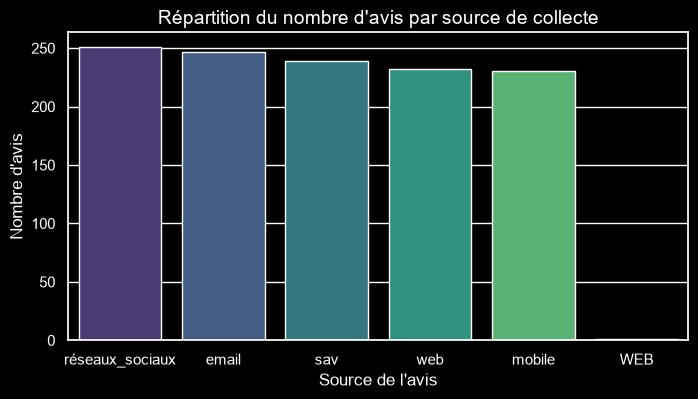

Détail des volumes par source :
source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


In [29]:
plt.figure(figsize=(8, 4))

# diagramme en barres trié par ordre décroissant
sns.countplot(
    data=df, 
    x='source', 
    order=df['source'].value_counts().index, 
    palette='viridis'
)

plt.title("Répartition du nombre d'avis par source de collecte", fontsize=14)
plt.xlabel("Source de l'avis", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)

plt.show()

# On affiche aussi les chiffres exacts juste en dessous
print("Détail des volumes par source :")
print(df['source'].value_counts())


#### Commentaire et analyse du graphique

* Omniprésence des canaux digitaux directs : On remarque que les avis proviennent de plateformes très diversifiées. Les canaux comme le web, le mobile et les réseaux_sociaux représentent une part massive du volume global. C'est tout à fait logique, car ce sont les endroits où il est le plus facile et instantané pour un client de laisser un commentaire.

* Le cas des canaux de support (sav et email) : Une part non négligeable des données remonte également du Service Après-Vente (sav) et des interactions par email.

* Lien avec la qualité du texte : Ce constat sur les sources explique la variété de styles textuels que l'on a observée à la question 6. Par exemple, les avis issus des réseaux_sociaux ou du mobile vont naturellement concentrer un maximum d'emojis, de hashtags, de texte en majuscules et de fautes de frappe. À l'inverse, les avis provenant des emails ou du sav contiennent plus souvent des structures de phrases formelles ou des mentions de type @client générées par des outils de billetterie informatique. Notre pipeline de nettoyage devra être assez robuste pour s'adapter à tous ces styles en même temps.